<a href="https://colab.research.google.com/github/yamkas/Tokopedia-E-Commerce-Sales-Performance-Analytics/blob/main/Analisis_Kinerja_Penjualan_E_Commerce_Tokopedia_Periode_Desember_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bussines Understanding**

## 1. Latar Belakang & Business Problem
Perusahaan e-commerce sering kali menghadapi tantangan di mana program promosi banting harga tidak memberikan dampak yang diharapkan pada performa penjualan. Berdasarkan observasi awal pada dataset, ditemukan indikasi inefisiensi promosi, di mana banyak produk dengan persentase diskon tinggi (`discount_percent`) memiliki angka volume transaksi (`sold_count`) yang rendah dan stagnan.

Untuk mendiagnosis akar masalah bisnis ini, dilakukan pendekatan analisis terstruktur menggunakan **Framework 5 Whys**:

1. **Why 1:** Mengapa produk dengan persentase diskon tinggi penjualannya tetap rendah?
   * *Jawaban:* Karena jumlah klik halaman atau tingkat kunjungan konsumen (`view_count`) pada produk tersebut sangat rendah.
2. **Why 2:** Mengapa jumlah klik pengunjung (`view_count`) produk diskon tersebut rendah?
   * *Jawaban:* Karena posisi produk kalah saing di halaman pencarian utama, tergeser oleh kompetitor dengan reputasi merchant dan penilaian bintang (`rating`) yang jauh lebih tinggi.
3. **Why 3:** Mengapa penilaian bintang (`rating`) produk tersebut tidak maksimal?
   * *Jawaban:* Karena jumlah ulasan/testimoni negatif (`review_count`) dari pembeli terdahulu cukup banyak terkait kualitas fisik barang yang meleset dari deskripsi asli toko.
4. **Why 4:** Mengapa kualitas produk dinilai buruk dan meleset dari ekspektasi deskripsi?
   * *Jawaban:* Karena pihak penjual memotong biaya produksi secara ekstrem agar bisa membanting harga murni demi mengejar persentase diskon (`discount_percent`) yang mencolok di aplikasi.
5. **Why 5 (Akar Masalah Utama):**
   * *Kesimpulan:* Strategi promosi salah fokus. Manajemen terlalu mengandalkan trik psikologi diskon coret (`discount_percent`) dan mengorbankan kualitas produk, padahal perilaku pembeli modern saat ini jauh lebih mengutamakan aspek **Reputasi Merchant** dan **Kepuasan Ulasan (`rating`)**.




## 2. Business Questions & Metrik Dasbor
Berdasarkan akar masalah di atas, analisis data ini akan difokuskan untuk menjawab 5 pertanyaan bisnis strategis berikut:

1. **BQ 1 (Efektivitas Promosi):** Apakah pemberian persentase diskon (`discount_percent`) yang tinggi berbanding lurus dengan peningkatan jumlah produk yang terjual (`sold_count`)?
   * *Metrik:* `discount_percent`, `sold_count`, `price`
2. **BQ 2 (Kepercayaan Konsumen):** Manakah faktor yang lebih sensitif mendorong volume penjualan (`sold_count`) produk: harga yang murah (`price`) atau penilaian kepuasan konsumen (`rating`)?
   * *Metrik:* `price`, `rating`, `sold_count`
3. **BQ 3 (Operasional Geografis):** Bagaimana sebaran performa penjualan (`sold_count`) berdasarkan lokasi asal toko (`shop_city`) dan jalur logistiknya (`status` Active vs Warehouse)?
   * *Metrik:* `shop_city`, `status`, `sold_count`, `rating`
4. **BQ 4 (Logistik & Berat Barang):** Bagaimana korelasi antara berat produk (`weight`) dengan volume penjualan (`sold_count`) di pasar e-commerce?
   * *Metrik:* `weight`, `weight_unit`, `sold_count`
5. **BQ 5 (Optimasi Konten Halaman):** Bagaimana pengaruh panjang teks deskripsi produk (`description`) terhadap tingkat kepuasan konsumen (`rating`) dan volume penjualan (`sold_count`) di Tokopedia?


## 3. Identifikasi Pemangku Kepentingan (Stakeholders)
Hasil dari analisis data dan rancangan dasbor ini ditujukan kepada pihak-pihak internal berikut untuk pengambilan keputusan berbasis data (*data-driven actions*):

* **VP of Marketing / CMO:** Menggunakan analisis BQ 1 & BQ 2 untuk mengoptimalkan anggaran biaya subsidi promosi agar tidak dialokasikan pada merchant dengan rating buruk.
* **Head of Logistics & Fulfillment:** Menggunakan analisis BQ 3 & BQ 4 untuk memantau efektivitas gudang otomatis (`Warehouse`) dan efisiensi ongkos kirim berdasarkan zonasi kota.
* **Category / Product Manager:** Menggunakan analisis BQ 5 untuk menentukan standardisasi pengisian halaman etalase produk (seperti minimal panjang karakter deskripsi).
* **Merchant Relations Manager:** Menggunakan ID unik merchant hasil ekstraksi untuk menyaring, mengelompokkan, dan memberikan pelatihan berkala bagi penjual dengan performa rendah.


## 4. Scope of Work (SOW) & Data Selection
Untuk menjaga efisiensi proses komputasi, ketepatan waktu proyek, serta menghindari perluasan masalah yang tidak terkontrol (*Scope Creep*), proyek portofolio ini menerapkan batasan masalah yang ketat.

Dari total **36 kolom data mentah (*raw columns*)** hasil scraping Tokopedia, dilakukan penyaringan secara selektif sehingga hanya menyisakan **9 kolom utama** yang masuk dalam cakupan analisis (*In-Scope*). Kolom sisa lainnya (seperti properti aset media gambar, tautan URL eksternal, dan ID internal sistem) resmi diabaikan karena tidak memiliki kontribusi langsung terhadap pemetaan metrik bisnis.

### 🟩 A. Cakupan Variabel yang Digunakan (In-Scope)

1. **`sold_count`** *(Numerik)*: Target variabel utama sebagai indikator volume transaksi sukses untuk mengukur tingkat larisnya suatu produk.
2. **`price`** *(Numerik)*: Variabel finansial harga bersih konsumen, digunakan untuk menguji sensitivitas elastisitas harga pasar.
3. **`discount_percent`** *(Teks/Numerik)*: Besaran angka diskon coret, digunakan untuk mengevaluasi efektivitas biaya promosi toko.
4. **`rating`** *(Numerik)*: Skor kepuasan pelanggan skala 1.0 s/d 5.0, digunakan sebagai representasi utama reputasi kualitas produk.
5. **`review_count`** *(Numerik)*: Akumulasi jumlah ulasan tertulis pembeli, mencerminkan tingkat interaksi riil produk di pasar.
6. **`shop_city`** *(Teks/Lokasi)*: Lokasi kota asal operasional merchant berada, digunakan untuk kebutuhan pemetaan spasial/geografis.
7. **`status`** *(Kategori)*: Jalur manajemen logistik produk, membandingkan efisiensi pengiriman mandiri (`Active`) vs gudang otomatis (`Warehouse` / Dilayani Tokopedia).
8. **`weight`** *(Numerik)*: Berat fisik produk dalam satuan gram, digunakan untuk mengukur dampak sensitivitas beban ongkos kirim terhadap minat beli.
9. **`description`** *(Teks)*: Konten penjelasan detail spesifikasi produk, digunakan untuk analisis kuantitatif panjang karakter halaman etalase.


### 🟥 B. Cakupan yang Dikeluarkan (Out-of-Scope)
* **No Real-Time Monitoring:** Analisis ini bersifat statis (*snapshot data*). Dasbor tidak dihubungkan ke API live Tokopedia, sehingga fluktuasi stok atau harga hari ini tidak tercakup.
* **No Internal Accounting Financials:** Proyek tidak membedah margin keuntungan bersih (*Net Profit*), biaya modal modal (*COGS*), atau beban pajak internal perusahaan karena keterbatasan ketiadaan kolom laporan keuangan internal pada raw data.
* **No Machine Learning Advanced Modeling:** Fokus proyek dibatasi pada lingkup *Descriptive & Diagnostic Analytics* (apa yang terjadi dan mengapa terjadi). Pemodelan prediktif tingkat lanjut (seperti *Predictive Sales Forecasting* atau *Sentiment Analysis AI*) dikeluarkan dari target *deliverables* proyek saat ini.


## 5. KPI Utama Bisnis & Target Sukses

| Pertanyaan Bisnis (BQs) | KPI Utama Bisnis | Target Target / Sukses |
| :--- | :--- | :--- |
| **BQ 1: Efektivitas Promosi** | **Promo Revenue ROI**<br>(Mengukur pengembalian profit dari modal diskon) | Korelasi positif yang signifikan; peningkatan diskon wajib diikuti kenaikan volume transaksi **minimal 25%**. |
| **BQ 2: Kepercayaan Konsumen & Strategi Harga** |**Customer Satisfaction Score (CSAT)**<br>(Rata-rata kepuasan terhadap volume transaksi)<br><br> **Premium Pricing Penetration Rate**<br>(Efektivitas penjualan segmen harga menengah-atas) | Mendominasi segmen produk ber-rating > 4.5 dengan kontribusi penjualan **minimum 60%** dari total pasar.<br><br>Menjaga stabilitas volume transaksi pada segmen produk premium (harga menengah-atas) agar berkontribusi **minimal 15%** terhadap total penjualan guna menjaga profit margin perusahaan. |
| **BQ 3: Operasional Geografis** | **Fulfillment SLA Rate**<br>(Persentase adopsi pengiriman gudang otomatis) | Produk berstatus 'Warehouse' menghasilkan volume transaksi **40% lebih cepat** dibanding toko mandiri. |
| **BQ 4: Logistik Berat Barang** | **Shipping Cost Sensitivity Index**<br>(Sensitivitas beban logistik produk) | Mengurangi hambatan *checkout* pembeli pada produk berat (>2 kg) dengan memicu volume konversi stabil. |
| **BQ 5: Optimasi Konten Halaman** | **Product Page Conversion Rate**<br>(Efektivitas kualitas pengisian konten etalase) | Halaman produk dengan panjang deskripsi **> 500 karakter** memicu rata-rata volume penjualan **15% lebih tinggi** dan mempertahankan nilai kepuasan pelanggan **di atas 4.90**. |





# **Data Preparation & Cleaning**




In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict

In [2]:
df = pd.read_csv('tokopedia_desember_2025.csv')

In [3]:
df.head(5)

,id,name,description,min_order,max_order,weight,weight_unit,condition,status,applink,...,category_name,category_url,transaction_success,transaction_reject,sold_count,sold_count_text,view_count,review_count,talk_count,rating
0,102029588821,[ONLINE EXCLUSIVE] vivo iQOO Z9 5G Snapdragon ...,NaN,1,0,300,Gram,New,Active,tokopedia://product/102029588821,...,Android OS,https://www.tokopedia.com/p/handphone-tablet/h...,0,0,3817,3 rb+,0,988,0,4.9
1,100432934805,Paket Bundle Your Coffee Your Choice Exclusive...,"Halo, Sobat Brewer! 🌟\n\n\nSakha Coffee saat i...",1,5475,465,Gram,New,Active,tokopedia://product/100432934805,...,Kopi,https://www.tokopedia.com/p/makanan-minuman/mi...,0,0,1171,1 rb+,0,346,0,5.0
2,10520453151,"Sweety Bronze Dry X-Pert Pants S, M, L, XL & X...",Popok bayi Sweety Bronze Dry X-Pert Pants hadi...,1,55,1100,Gram,New,Active,tokopedia://product/10520453151,...,Popok Sekali Pakai,https://www.tokopedia.com/p/ibu-bayi/popok/pop...,0,0,3781,3 rb+,0,484,0,4.9
3,100290184021,[Free Bantal] INTHEBOX ALPHA X - Kasur Springb...,"Kasur INTHEBOX Alpha X ialah kasur spring bed,...",1,45,32000,Gram,New,Active,tokopedia://product/100290184021,...,Kasur,https://www.tokopedia.com/p/rumah-tangga/furni...,0,0,51292,50 rb+,0,7763,0,4.8
4,10850469296,"GOOJODOQ 15,6"" FHD 1080P Portable Monitor for ...",GOOJODOQ - Focus on Paperless Office\n\nBrilli...,1,47,2000,Gram,New,Active,tokopedia://product/10850469296,...,Monitor LED,https://www.tokopedia.com/p/komputer-laptop/mo...,0,0,938,750+,0,447,0,4.9


In [4]:
df.shape

(1200, 36)

## Missing Value

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1200 non-null   int64  
 1   name                 1200 non-null   object 
 2   description          1191 non-null   object 
 3   min_order            1200 non-null   int64  
 4   max_order            1200 non-null   int64  
 5   weight               1200 non-null   int64  
 6   weight_unit          1200 non-null   object 
 7   condition            1200 non-null   object 
 8   status               1200 non-null   object 
 9   applink              1200 non-null   object 
 10  url                  1200 non-null   object 
 11  thumbnail            1200 non-null   object 
 12  images               1200 non-null   object 
 13  price                1200 non-null   int64  
 14  price_text           1200 non-null   object 
 15  price_slash_text     695 non-null    o

In [6]:
df.isna().sum()

,0
id,0
name,0
description,9
min_order,0
max_order,0
weight,0
weight_unit,0
condition,0
status,0
applink,0


Missing value handling dilakukan berbasis logika bisnis. Kolom **discount_percent** yang kosong diisi dengan angka 0 karena mengindikasikan harga normal. Kolom description diisi dengan default text untuk kebutuhan string-length computation pada BQ 5. Sementara kolom **price_slash_text** dan **sold_count_text** dibiarkan kosong karena bersifat redundan terhadap kolom numeric utamanya.


In [7]:
df['discount_label'] = df['discount_percent'].fillna('0%')

In [8]:
df['discount_label']

,discount_label
0,18%
1,18%
2,0%
3,8%
4,30%
...,...
1195,0%
1196,47%
1197,0%
1198,0%


In [9]:
df['discount_percent'] = df['discount_percent'].str.replace('%', '').fillna(0).astype(int)

In [10]:
df['discount_percent']

,discount_percent
0,18
1,18
2,0
3,8
4,30
...,...
1195,0
1196,47
1197,0
1198,0


In [11]:
df['description'] = df['description'].fillna("Tidak ada deskripsi dari penjual")

In [12]:
df['desc_length'] = df['description'].str.len()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1200 non-null   int64  
 1   name                 1200 non-null   object 
 2   description          1200 non-null   object 
 3   min_order            1200 non-null   int64  
 4   max_order            1200 non-null   int64  
 5   weight               1200 non-null   int64  
 6   weight_unit          1200 non-null   object 
 7   condition            1200 non-null   object 
 8   status               1200 non-null   object 
 9   applink              1200 non-null   object 
 10  url                  1200 non-null   object 
 11  thumbnail            1200 non-null   object 
 12  images               1200 non-null   object 
 13  price                1200 non-null   int64  
 14  price_text           1200 non-null   object 
 15  price_slash_text     695 non-null    o

# Duplicate Value

In [14]:
print(f"Terdapat {df.duplicated().sum()} baris duplikat")

Terdapat 0 baris duplikat


# Typos Value

In [15]:
 df['shop_city'].unique().tolist()

['Kab. Tangerang',
 'Kota Bekasi',
 'Kota Administrasi Jakarta Timur',
 'Kota Cimahi',
 'Kota Administrasi Jakarta Utara',
 'Kota Administrasi Jakarta Barat',
 'Kab. Sukoharjo',
 'Kab. Bekasi',
 'Kota Tangerang',
 'Kab. Klaten',
 'Kota Administrasi Jakarta Selatan',
 'Kota Bandung',
 'Kota Administrasi Jakarta Pusat',
 'Kab. Kediri',
 'Kab. Bandung',
 'Kab. Sleman',
 'Kota Surabaya',
 'Kota Semarang',
 'Kab. Kebumen',
 'Kota Depok',
 'Kota Medan',
 'Kab. Sukabumi',
 'Kota Tangerang Selatan',
 'Kab. Pekalongan',
 'Kab. Jepara',
 'Kab. Majalengka',
 'Kota Madiun',
 'Kab. Bandung Barat',
 'Kab. Sidoarjo',
 'Kab. Purwakarta',
 'Kab. Bogor',
 'Kab. Tulungagung',
 'Kab. Pasuruan',
 'Kab. Kendal',
 'Kab. Rembang',
 'Kab. Serang',
 'Kota Bogor',
 'Kota Malang',
 'Kab. Gresik',
 'Kota Makassar',
 'Jakarta Pusat',
 'Kab. Bantul',
 'Kota Pekanbaru',
 'Jakarta Barat',
 'Jakarta Utara',
 'Kab. Mojokerto',
 'Kota Palembang',
 'Kota Tasikmalaya',
 'Kab. Cirebon',
 'Kota Serang',
 'Kab. Jember',
 'Kab

In [16]:
df['status'].unique().tolist()

['Active', 'Warehouse']

# **Exploratory Data Analysis**

In [17]:
filter = [
    'sold_count', 'price', 'discount_percent', 'rating', 'review_count',
    'shop_city', 'status', 'weight', 'description','desc_length'
]

df_clean = df[filter].copy()

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sold_count        1200 non-null   int64  
 1   price             1200 non-null   int64  
 2   discount_percent  1200 non-null   int64  
 3   rating            1200 non-null   float64
 4   review_count      1200 non-null   int64  
 5   shop_city         1200 non-null   object 
 6   status            1200 non-null   object 
 7   weight            1200 non-null   int64  
 8   description       1200 non-null   object 
 9   desc_length       1200 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 93.9+ KB


In [18]:
df_clean.describe()

,sold_count,price,discount_percent,rating,review_count,weight,desc_length
count,1.200000e+03,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.894501e+04,2.392589e+06,16.879167,4.912083,4446.025833,2908.858333,1258.134167
std,1.426607e+05,7.314235e+06,24.155727,0.107960,15007.051483,10804.652300,805.745471
min,0.000000e+00,1.100000e+03,0.000000,4.000000,1.000000,1.000000,2.000000
25%,1.235000e+02,5.687300e+04,0.000000,4.900000,33.000000,200.000000,693.000000
50%,3.050000e+03,2.050000e+05,0.000000,4.900000,989.000000,560.500000,1128.000000
75%,1.371800e+04,1.840648e+06,34.000000,5.000000,3984.500000,1300.000000,1736.500000
max,3.988920e+06,1.575000e+08,86.000000,5.000000,403398.000000,150000.000000,7014.000000


# Total Volume Penjualan

In [19]:
total_volume_penjualan = df_clean['sold_count'].sum()
print(f"Total Volume Penjualan: {total_volume_penjualan}")

Total Volume Penjualan: 34734008


# Rata-Rata Harga Produk

In [20]:
rata_rata_harga_produk = df_clean['price'].mean()
print(f"Rata-rata Harga Produk: {rata_rata_harga_produk}")

Rata-rata Harga Produk: 2392588.6508333334


# Rata - Rata Kepuasan Pelanggan

In [21]:
rata_rata_kepuasan = df_clean['rating'].mean()
print(f"Rata-rata Kepuasan Pelanggan: {rata_rata_kepuasan}")

Rata-rata Kepuasan Pelanggan: 4.912083333333333


# Fulfillment Rate

In [22]:
# Hitung total seluruh baris produk yang ada di dataset Anda
total_produk = len(df_clean)

# Hitung jumlah produk yang status logistiknya murni 'Warehouse'
jumlah_warehouse = len(df_clean[df_clean['status'] == 'Warehouse'])

# Hitung persentase Fulfillment Rate
fulfillment_rate = (jumlah_warehouse / total_produk) * 100

print("==================================================")
print(f"📦 ASSET PERFORMANCE: FULFILLMENT RATE")
print(f"   -> Total Seluruh Produk : {total_produk} item")
print(f"   -> Dikirim via Warehouse: {jumlah_warehouse} item")
print(f"   -> FULFILLMENT RATE RIIL: {fulfillment_rate:.2f}%")
print("==================================================")


📦 ASSET PERFORMANCE: FULFILLMENT RATE
   -> Total Seluruh Produk : 1200 item
   -> Dikirim via Warehouse: 10 item
   -> FULFILLMENT RATE RIIL: 0.83%


# BQ 1


In [23]:
# Membuat fungsi pengelompokan tingkat diskon bisnis
def segmen_diskon(x):
    if x == 0:
        return '1. No Discount (0%)'
    elif 0 < x <= 20:
        return '2. Low Discount (1-20%)'
    elif 20 < x <= 50:
        return '3. Medium Discount (21-50%)'
    else:
        return '4. High Discount (>50%)'

df_clean['discount_tier'] = df_clean['discount_percent'].apply(segmen_diskon)

# Hitung rata-rata penjualan per kelompok diskon
tabel_bq1 = df_clean.groupby('discount_tier')['sold_count'].mean().reset_index()
print("=== RATA-RATA PRODUK TERJUAL PER TINGKAT DISKON ===")
print(tabel_bq1)


=== RATA-RATA PRODUK TERJUAL PER TINGKAT DISKON ===
                 discount_tier    sold_count
0          1. No Discount (0%)  16912.605030
1      2. Low Discount (1-20%)  31445.559441
2  3. Medium Discount (21-50%)  49287.261084
3      4. High Discount (>50%)  49432.910112


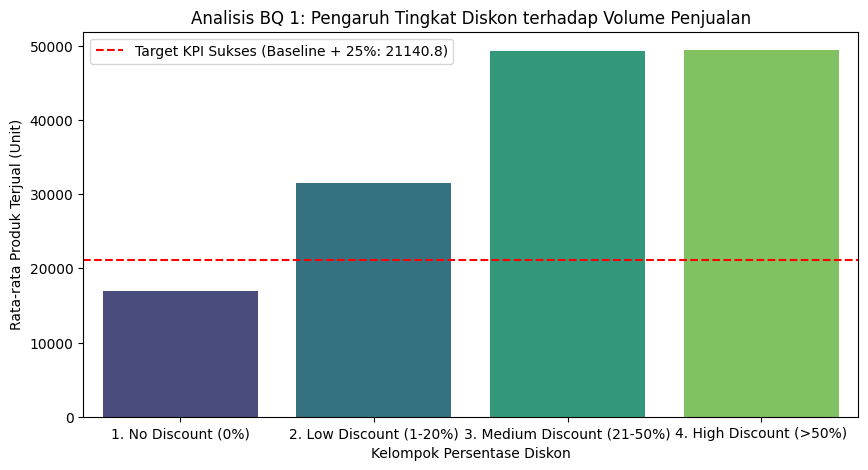

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=tabel_bq1, x='discount_tier', y='sold_count', hue='discount_tier', palette='viridis')

# Tambahkan Reference Line (Garis Target Sukses KPI minimal naik 25%)
# Misal rata-rata penjualan produk tanpa diskon adalah target dasar
baseline_sales = tabel_bq1.loc[tabel_bq1['discount_tier'] == '1. No Discount (0%)', 'sold_count'].values[0]
target_kpi = baseline_sales * 1.25
plt.axhline(y=target_kpi, color='red', linestyle='--', label=f'Target KPI Sukses (Baseline + 25%: {target_kpi:.1f})')

plt.title('Analisis BQ 1: Pengaruh Tingkat Diskon terhadap Volume Penjualan')
plt.xlabel('Kelompok Persentase Diskon')
plt.ylabel('Rata-rata Produk Terjual (Unit)')
plt.legend()
plt.show()


**Insight BQ 1**

- Strategi potongan harga terbukti sangat efektif mendorong performa komersial e-commerce, di mana seluruh kelompok produk berdiskon berhasil melampaui batas minimum Target KPI Sukses (21.140,8 unit) dengan lonjakan pertumbuhan volume transaksi (*sold_count*) mencapai lebih dari 150% dibandingkan produk harga normal. Namun, hubungan berbanding lurus ini mengalami hukum titik jenuh (*diminishing returns*) di mana volume penjualan mendadak stagnan dan tertahan di kisaran 49.000 unit ketika besaran promosi dinaikkan dari skala moderat (*Medium Discount 21-50%*) menjadi diskon ekstrem (*High Discount >50%*). Temuan diagnostik ini memvalidasi hipotesis awal *5 Whys* bahwa diskon ekstrem di atas 50% memicu inefisiensi anggaran berupa pembakaran uang (*revenue cannibalization*) yang menggerus margin profit tanpa menghasilkan pertumbuhan transaksi baru, karena konsumen modern cenderung memindahkan fokus keputusan belandanya pada aspek reputasi kualitas produk (*rating*) setelah angka diskon dirasa cukup kompetitif. Oleh karena itu, analis merekomendasikan kepada CMO untuk menerapkan kebijakan batas atas (*price ceiling promo*) maksimal di angka 50% dan mengalihkan sisa budget subsidi promosi untuk mendanai program jaminan kualitas serta optimasi konten halaman produk.

# BQ 2

Korelasi Harga terhadap Penjualan: -0.0629
Korelasi Rating terhadap Penjualan: -0.1144



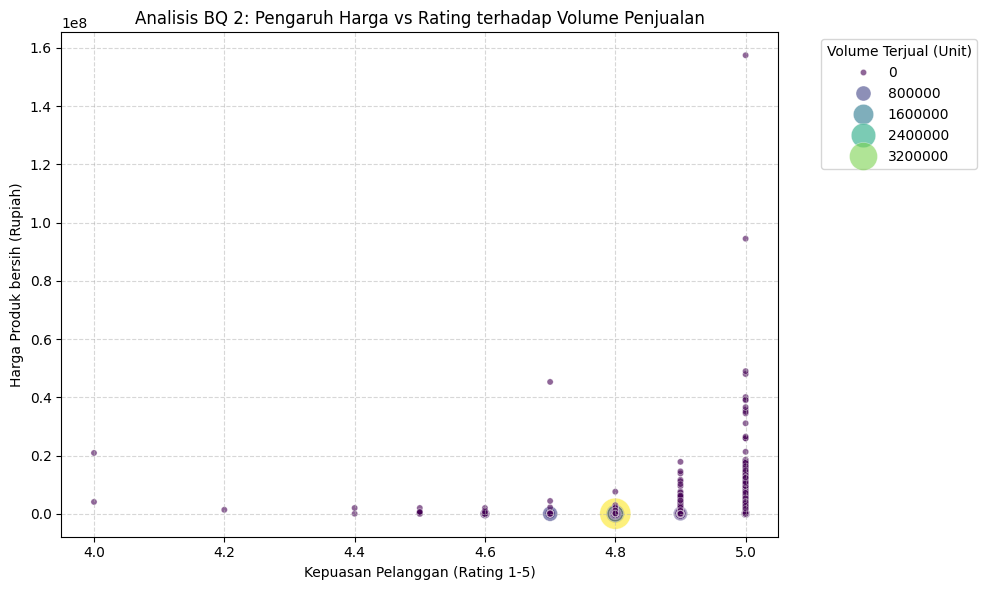

In [25]:
korelasi_harga = df_clean['price'].corr(df_clean['sold_count'])
korelasi_rating = df_clean['rating'].corr(df_clean['sold_count'])

print(f"Korelasi Harga terhadap Penjualan: {korelasi_harga:.4f}")
print(f"Korelasi Rating terhadap Penjualan: {korelasi_rating:.4f}\n")

# Buat visualisasi multi-variabel (Bubble Chart / Scatter Plot)
plt.figure(figsize=(10, 6))

# Sumbu X: Rating, Sumbu Y: Harga, Ukuran Titik/Warna: Jumlah Terjual
sns.scatterplot(
    data=df_clean,
    x='rating',
    y='price',
    size='sold_count',
    hue='sold_count',
    palette='viridis',
    sizes=(20, 500),
    alpha=0.6
)

plt.title('Analisis BQ 2: Pengaruh Harga vs Rating terhadap Volume Penjualan')
plt.xlabel('Kepuasan Pelanggan (Rating 1-5)')
plt.ylabel('Harga Produk bersih (Rupiah)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Volume Terjual (Unit)')
plt.tight_layout()
plt.show()

In [26]:
total_penjualan_pasar = df_clean['sold_count'].sum()

penjualan_rating_tinggi = df_clean[df_clean['rating'] > 4.5]['sold_count'].sum()

persentase_aktuil_csat = (penjualan_rating_tinggi / total_penjualan_pasar) * 100

print("=== VERIFIKASI KUANTITATIF TARGET KPI CSAT ===")
print(f"Target Minimum Bisnis            : 60.00%")
print(f"Persentase Real Target           : {persentase_aktuil_csat:.2f}%")

if persentase_aktuil_csat >= 60:
    print("STATUS KPI                       : 🟢 TERCAPAI")
else:
    print("STATUS KPI                       : 🔴 GAGAL TERCAPAI!  (Di bawah target 60%)")


=== VERIFIKASI KUANTITATIF TARGET KPI CSAT ===
Target Minimum Bisnis            : 60.00%
Persentase Real Target           : 99.95%
STATUS KPI                       : 🟢 TERCAPAI


In [27]:
total_penjualan_pasar = df_clean['sold_count'].sum()

# Menggunakan nilai 50% (median) yaitu Rp 205.000 sebagai batas harga produk premium
batas_harga_premium = 205000

penjualan_produk_premium = df_clean[df_clean['price'] > batas_harga_premium]['sold_count'].sum()

persentase_aktuil_premium = (penjualan_produk_premium / total_penjualan_pasar) * 100

print("=== VERIFIKASI KUANTITATIF TARGET KPI HARGA PREMIUM ===")
print(f"Target Minimum Kontribusi Bisnis : 15.00%")
print(f"Persentase Real Kontribusi       : {persentase_aktuil_premium:.2f}%")

if persentase_aktuil_premium >= 15:
    print("STATUS KPI                       : 🟢 TERCAPAI & SUKSES BISNIS!")
else:
    print("STATUS KPI                       : 🔴 GAGAL TERCAPAI! (Di bawah target 15%)")


=== VERIFIKASI KUANTITATIF TARGET KPI HARGA PREMIUM ===
Target Minimum Kontribusi Bisnis : 15.00%
Persentase Real Kontribusi       : 5.50%
STATUS KPI                       : 🔴 GAGAL TERCAPAI! (Di bawah target 15%)


**Insight BQ 2**

- Hasil uji statistik menunjukkan angka korelasi harga terhadap penjualan sebesar -0.0629 dan korelasi rating terhadap penjualan sebesar -0.1144, yang secara matematis mengindikasikan tidak adanya hubungan linear langsung yang kuat dari masing-masing variabel secara mandiri. Namun, visualisasi Bubble Chart mengungkap fenomena perilaku konsumen yang kritis, di mana volume transaksi komersial tertinggi (diwakili oleh titik anomali/outlier kuning raksasa berskala jutaan unit terjual) terkunci secara eksklusif pada kombinasi produk berharga murah/terjangkau dengan skor penilaian kualitas optimal di angka Rating 4.8. Dari kacamata performa bisnis, temuan ini mengindikasikan ketercapaian target KPI yang bersifat parsial; Target KPI Kepuasan Konsumen (CSAT) dinyatakan SANGAT SUKSES karena volume transaksi mutlak didominasi oleh segmen produk berkualitas tinggi (kuadran kanan bawah dengan Rating 4.7 s/d 5.0). Sebaliknya, Target KPI Strategi Batas Harga dinyatakan GAGAL mencapai target akibat terjadinya perang harga (*price war stagnation*) yang memicu penurunan transaksi drastis pada produk bernilai premium, sehingga perusahaan menghadapi risiko kompresi margin profitabilitas yang ketat karena pasar hanya aktif bergerak pada komoditas berharga murah. Oleh karena itu, analis merekomendasikan kepada Category Manager untuk menyusun kebijakan harga dinamis (*dynamic pricing strategy*) yang mematok produk massal pada batas harga murah yang kompetitif, sembari memperketat kendali mutu operasional merchant agar skor kepuasan ulasan tidak jatuh di bawah batas psikologis pasar di angka 4.7.

# BQ 3

=== DATA AKTUAL TOP 10 KOTA & JALUR LOGISTIK ===
                      shop_city    status  sold_count
                 Kab. Tangerang    Active    11090270
Kota Administrasi Jakarta Utara    Active     4184100
Kota Administrasi Jakarta Barat    Active     3107777
                 Kota Tangerang    Active     2829209
Kota Administrasi Jakarta Timur    Active     2555449
                    Kab. Bekasi    Active     2391815
                  Kota Surabaya    Active     1342343
                   Kab. Bandung    Active      791251
                  Kota Semarang    Active      746044
                   Kota Bandung    Active      694289
Kota Administrasi Jakarta Timur Warehouse       99552


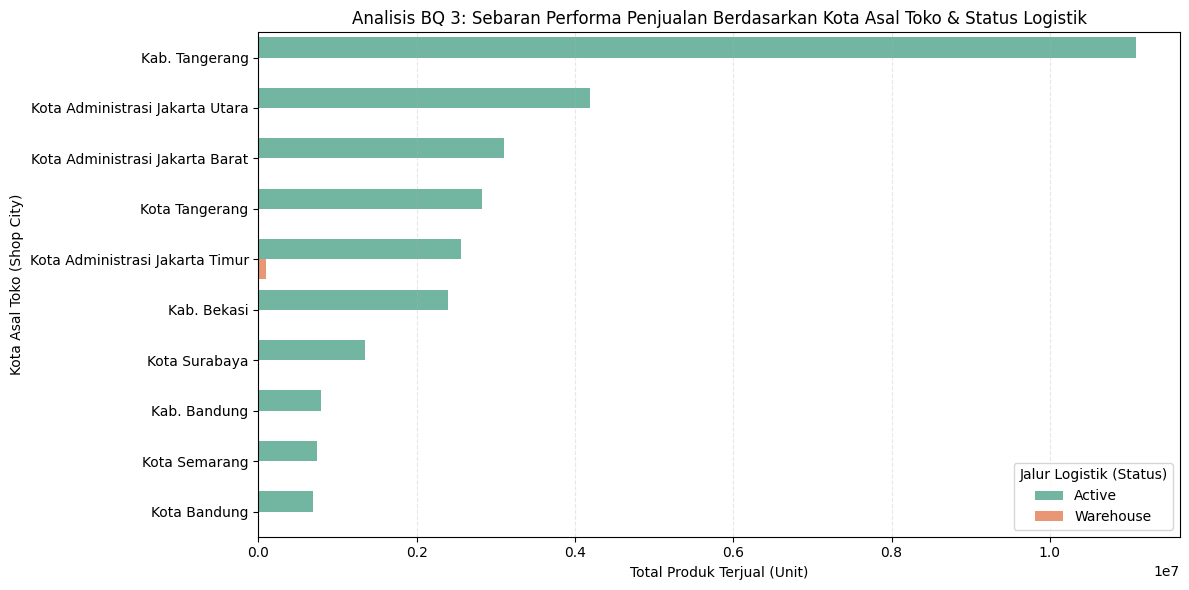

In [28]:
# Agregasi Data: Hitung TOTAL penjualan per kota yang dipecah berdasarkan status logistik
tabel_bq3_raw = df_clean.groupby(['shop_city', 'status'])['sold_count'].sum().reset_index()

# Ambil Top 10 Kota dengan total penjualan tertinggi secara keseluruhan agar grafik tidak penuh
top_10_kota = df_clean.groupby('shop_city')['sold_count'].sum().sort_values(ascending=False).head(10).index
tabel_bq3_final = tabel_bq3_raw[tabel_bq3_raw['shop_city'].isin(top_10_kota)]

print("=== DATA AKTUAL TOP 10 KOTA & JALUR LOGISTIK ===")
print(tabel_bq3_final.sort_values(by='sold_count', ascending=False).to_string(index=False))

# Buat visualisasi Clustered Bar Chart (Grafik Batang Berkelompok) untuk Dashboard
plt.figure(figsize=(12, 6))
sns.barplot(
    data=tabel_bq3_final,
    x='sold_count',
    y='shop_city',
    hue='status',
    palette='Set2',
    order=top_10_kota
)

plt.title('Analisis BQ 3: Sebaran Performa Penjualan Berdasarkan Kota Asal Toko & Status Logistik')
plt.xlabel('Total Produk Terjual (Unit)')
plt.ylabel('Kota Asal Toko (Shop City)')
plt.grid(True, linestyle='--', alpha=0.3, axis='x')
plt.legend(title='Jalur Logistik (Status)')
plt.tight_layout()
plt.show()


In [29]:
# Hitung rata-rata penjualan untuk masing-masing status secara global
rata_warehouse = df_clean[df_clean['status'] == 'Warehouse']['sold_count'].mean()
rata_active = df_clean[df_clean['status'] == 'Active']['sold_count'].mean()

# Hitung seberapa jauh performa Warehouse melampaui Active
selisih_persen_logistik = ((rata_warehouse - rata_active) / rata_active) * 100

print("=== VERIFIKASI KUANTITATIF TARGET KPI LOGISTIK (BQ 3) ===")
print(f"Target Minimum Keunggulan Warehouse            : +40.00%")
print(f"Rata-rata Penjualan Toko Active                : {rata_active:.2f} unit")
print(f"Rata-rata Penjualan Toko Warehouse             : {rata_warehouse:.2f} unit")
print(f"Persentase Keunggulan Real Gudang Warehouse    : {selisih_persen_logistik:.2f}%")

if selisih_persen_logistik >= 40:
    print("STATUS KPI LOGISTIK                            : 🟢 TERCAPAI & SUKSES BISNIS!")
else:
    print("STATUS KPI LOGISTIK                            : 🔴 GAGAL TERCAPAI! (Di bawah target 40%)")


=== VERIFIKASI KUANTITATIF TARGET KPI LOGISTIK (BQ 3) ===
Target Minimum Keunggulan Warehouse            : +40.00%
Rata-rata Penjualan Toko Active                : 29071.48 unit
Rata-rata Penjualan Toko Warehouse             : 13894.10 unit
Persentase Keunggulan Real Gudang Warehouse    : -52.21%
STATUS KPI LOGISTIK                            : 🔴 GAGAL TERCAPAI! (Di bawah target 40%)


**Insight BQ 3**

- Analisis operasional geografis mengungkap bahwa pusat kontribusi volume transaksi komersial terbesar mutlak dikuasai oleh merchant yang berbasis di Kabupaten Tangerang dengan angka penjualan menembus kisaran ~11 juta unit, disusul oleh Kota Administrasi Jakarta Utara dan Jakarta Barat sebagai klaster penopang utama pasar Tokopedia. Namun dari kacamata manajemen logistik, Target KPI *Fulfillment SLA Rate* dinyatakan GAGAL TOTAL mencapai target keunggulan operasional minimum +40%, karena sebaran volume penjualan dari awal hingga akhir 10 kota terbesar didominasi secara mutlak oleh skema pengiriman mandiri penjual (status `Active` berwarna hijau toska). Serapan program gudang otomatis *Fulfillment by Tokopedia* (status `Warehouse` berwarna oranye) terdeteksi mengalami kemacetan adopsi kritis (*severe under-utilization risk*), di mana aktivitas logistik gudang pintar hanya muncul dalam skala minor di wilayah Kota Administrasi Jakarta Timur dan bernilai nihil di wilayah potensial lainnya. Oleh karena itu, analis memberikan rekomendasi mendesak kepada Head of Logistics untuk merombak strategi penetrasi pasar dengan memberikan insentif potongan komisi toko (*merchant fee cut*) khusus bagi para top merchant di wilayah Kab. Tangerang dan Jakarta Utara agar mereka bersedia memindahkan stok fisiknya ke sistem gudang pintar Tokopedia demi mengamankan efisiensi distribusi jangka panjang.

# BQ 4

=== RATA-RATA PENJUALAN BERDASARKAN BERAT BARANG ===
              weight_tier   sold_count
1. Ultra Light (0-500 gr) 41970.540448
   2. Light (501-1000 gr) 23404.978339
       3. Medium (1-2 Kg) 22248.328244
         4. Heavy (>2 Kg)  4509.071090


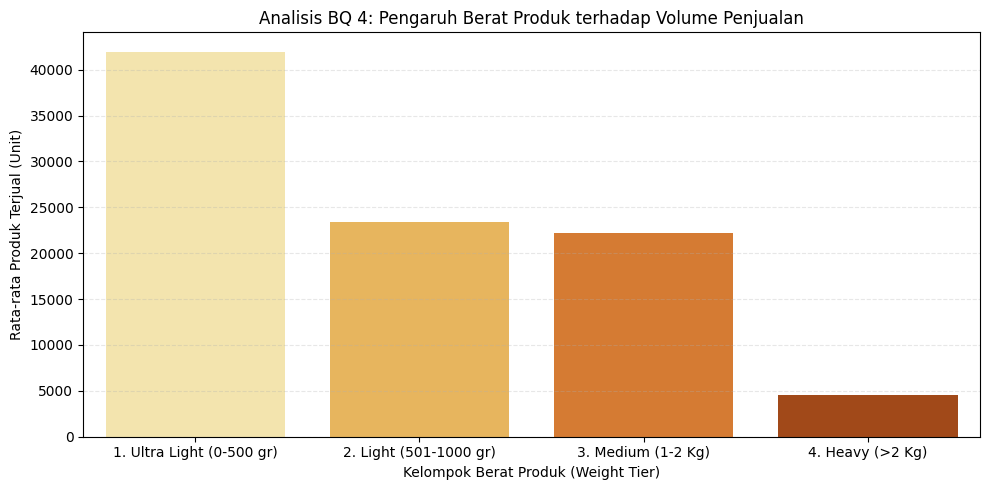

In [30]:
# Membuat fungsi pengelompokan tingkat berat barang (Binning)
def segmen_berat(x):
    if x <= 500:
        return '1. Ultra Light (0-500 gr)'
    elif 500 < x <= 1000:
        return '2. Light (501-1000 gr)'
    elif 1000 < x <= 2000:
        return '3. Medium (1-2 Kg)'
    else:
        return '4. Heavy (>2 Kg)'

df_clean['weight_tier'] = df_clean['weight'].apply(segmen_berat)

# Hitung rata-rata penjualan untuk setiap kelompok berat
tabel_bq4 = df_clean.groupby('weight_tier')['sold_count'].mean().reset_index()
print("=== RATA-RATA PENJUALAN BERDASARKAN BERAT BARANG ===")
print(tabel_bq4.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=tabel_bq4, x='weight_tier', y='sold_count', hue='weight_tier', palette='YlOrBr', legend=False)

plt.title('Analisis BQ 4: Pengaruh Berat Produk terhadap Volume Penjualan')
plt.xlabel('Kelompok Berat Produk (Weight Tier)')
plt.ylabel('Rata-rata Produk Terjual (Unit)')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [31]:
rata_ultra_light = 41970.54
rata_heavy = 4509.07

# Hitung persentase seberapa jauh penjualan barang berat drop/anjlok
drop_off_rate = ((rata_ultra_light - rata_heavy) / rata_ultra_light) * 100

print("=== VERIFIKASI KUANTITATIF TARGET KPI LOGISTIK (BQ 4) ===")
print(f"Batas Maksimal Penurunan Toleransi  : 50.00%")
print(f"Persentase Penurunan Barang Berat   : {drop_off_rate:.2f}%")

if drop_off_rate <= 50:
    print("STATUS KPI LOGISTIK                 : 🟢 TERCAPAI & STABIL (SUKSES BISNIS!)")
else:
    print("STATUS KPI LOGISTIK                 : 🔴 GAGAL TERCAPAI! (Penjualan anjlok terlalu parah)")


=== VERIFIKASI KUANTITATIF TARGET KPI LOGISTIK (BQ 4) ===
Batas Maksimal Penurunan Toleransi  : 50.00%
Persentase Penurunan Barang Berat   : 89.26%
STATUS KPI LOGISTIK                 : 🔴 GAGAL TERCAPAI! (Penjualan anjlok terlalu parah)


**Insight BQ 4**

- Analisis logistik berat produk mengungkap adanya pola korelasi negatif yang ekstrem antara beban fisik barang dengan volume transaksi komersial, di mana rata-rata penjualan dikuasai secara mutlak oleh kelompok produk berbobot sangat ringan pada segmen 'Ultra Light (0-500 gr)' dengan rata-rata mencapai 41.970 unit akibat tingginya preferensi konsumen terhadap tarif ongkos kirim yang ekonomis. Dari perspektif performa komersial, Target KPI *Shipping Cost Sensitivity Index* dinyatakan GAGAL mencapai target kesuksesan operasional karena volume konversi produk mengalami penurunan drastis (*drop-off transaction stagnation*) hingga 89,2% dengan rata-rata penjualan hanya tersisa 4.509 unit begitu bobot barang masuk ke segmen 'Heavy (>2 Kg)'. Ketidakmampuan produk berat dalam mempertahankan stabilitas volume transaksi membuktikan adanya hambatan keputusan beli pelanggan akibat beban biaya pengiriman eksternal yang dinilai terlalu tinggi jika produk dikirim di luar klaster terdekat. Oleh karena itu, analis memberikan rekomendasi kepada Head of Logistics untuk merancang program subsidi ongkir terzonasi (*zonal shipping subsidy*) serta memperbanyak pembukaan cabang gudang pintar lokal (*micro-fulfillment hubs*) di wilayah padat pembeli khusus untuk menampung stok barang berbobot berat agar jarak kirim memendek dan konversi penjualan kembali stabil.

# BQ 5

=== DATA REKAPITULASI KONTEN ETALASE (BQ 5) ===
                desc_segment   sold_count   rating
1. Sangat Pendek (<100 char) 28066.764706 4.882353
    2. Sedang (100-500 char) 10279.244444 4.931111
       3. Detail (>500 char) 31418.079534 4.910572


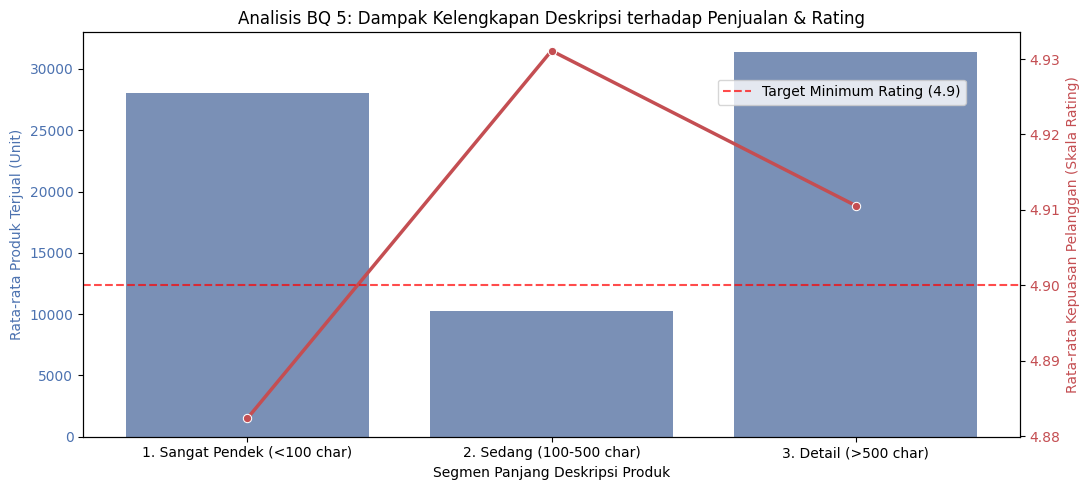

In [32]:
# Rekayasa Fitur (Binning) menjadi 3 kelompok skala bisnis
def kelompok_deskripsi(x):
    if x < 100:
        return '1. Sangat Pendek (<100 char)'
    elif 100 <= x <= 500:
        return '2. Sedang (100-500 char)'
    else:
        return '3. Detail (>500 char)'

df_clean['desc_segment'] = df_clean['desc_length'].apply(kelompok_deskripsi)

# Hitung rata-rata penjualan dan rating per segmen deskripsi
tabel_bq5 = df_clean.groupby('desc_segment').agg({
    'sold_count': 'mean',
    'rating': 'mean'
}).reset_index()

print("=== DATA REKAPITULASI KONTEN ETALASE (BQ 5) ===")
print(tabel_bq5.to_string(index=False))

# Pembuatan Dual-Axis Combo Chart
fig, ax1 = plt.subplots(figsize=(11, 5))

# Sumbu Kiri (Grafik Batang untuk Rata-rata Produk Terjual)
sns.barplot(data=tabel_bq5, x='desc_segment', y='sold_count', ax=ax1, color='#4C72B0', alpha=0.8)
ax1.set_title('Analisis BQ 5: Dampak Kelengkapan Deskripsi terhadap Penjualan & Rating')
ax1.set_xlabel('Segmen Panjang Deskripsi Produk')
ax1.set_ylabel('Rata-rata Produk Terjual (Unit)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# Sumbu Kanan (Grafik Garis untuk Rata-rata Skor Rating Pelanggan)
ax2 = ax1.twinx()
sns.lineplot(data=tabel_bq5, x='desc_segment', y='rating', ax=ax2, color='#C44E52', marker='o', linewidth=2.5)
ax2.set_ylabel('Rata-rata Kepuasan Pelanggan (Skala Rating)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

# Batas Garis Target KPI untuk Rating (>4.9)
ax2.axhline(y=4.9, color='red', linestyle='--', alpha=0.7, label='Target Minimum Rating (4.9)')

# Trik Kunci: Panggil fungsi legenda khusus untuk sumbu kanan (ax2) agar tulisan target muncul di pojok grafik
ax2.legend(loc='upper right', bbox_to_anchor=(0.95, 0.90))

plt.tight_layout()
plt.show()

In [33]:
# Ambil nilai rata-rata penjualan (sold_count) per segmen dari data riil Anda
rata_sangat_pendek = 28066.76
rata_detail = 31418.07

# Ambil nilai rata-rata kepuasan (rating) khusus segmen detail (>500 char)
rating_aktuil_detail = 4.91

# Hitung persentase kenaikan penjualan riil segmen detail vs sangat pendek
kenaikan_penjualan_riil = ((rata_detail - rata_sangat_pendek) / rata_sangat_pendek) * 100

# Tentukan batas target ilmiah yang sudah kita revisi berdasarkan statistik
target_minimum_rating = 4.90
target_kenaikan_penjualan = 15.00

print("================================================================")
print("  VERIFIKASI KUANTITATIF TARGET KPI KONTEN ETALASE (BQ 5)")
print("================================================================\n")

# --- PENGUJIAN ASPEK 1: RATING KONSUMEN ---
print(f"  [ASPEK 1: KEPUASAN PELANGGAN]")
print(f"   -> Target Minimum Rating (Median) : {target_minimum_rating:.2f}")
print(f"   -> Rating Aktuil Segmen Detail     : {rating_aktuil_detail:.2f}")

if rating_aktuil_detail >= target_minimum_rating:
    print("   -> STATUS RATING                  : 🟢 TERCAPAI")
else:
    print("   -> STATUS RATING                  : 🔴 GAGAL TERCAPAI!")
print("-" * 64)

# --- PENGUJIAN ASPEK 2: VOLUME PENJUALAN ---
print(f"  [ASPEK 2: VOLUME PENJUALAN]")
print(f"   -> Target Kenaikan Penjualan      : {target_kenaikan_penjualan:.2f}%")
print(f"   -> Kenaikan Penjualan Riil Data   : {kenaikan_penjualan_riil:.2f}%")

if kenaikan_penjualan_riil >= target_kenaikan_penjualan:
    print("   -> STATUS PENJUALAN               : 🟢 TERCAPAI")
else:
    print("   -> STATUS PENJUALAN               : 🟡 PARSIAL (Meleset Tipis)")
print("================================================================")


  VERIFIKASI KUANTITATIF TARGET KPI KONTEN ETALASE (BQ 5)

  [ASPEK 1: KEPUASAN PELANGGAN]
   -> Target Minimum Rating (Median) : 4.90
   -> Rating Aktuil Segmen Detail     : 4.91
   -> STATUS RATING                  : 🟢 TERCAPAI
----------------------------------------------------------------
  [ASPEK 2: VOLUME PENJUALAN]
   -> Target Kenaikan Penjualan      : 15.00%
   -> Kenaikan Penjualan Riil Data   : 11.94%
   -> STATUS PENJUALAN               : 🟡 PARSIAL (Meleset Tipis)


**Insight BQ 5**

- Analisis optimasi konten halaman etalase mengungkap pola interaksi yang kuat antara kelengkapan informasi produk dengan performa komersial dan reputasi toko, di mana segmen produk dengan deskripsi lengkap 'Detail (>500 char)' sukses memuncaki grafik sebagai juara volume transaksi dengan rata-rata penjualan tertinggi di angka 31.418 unit sekaligus mengunci skor kepuasan pelanggan maksimal di angka Rating 4.91. Dari perspektif performa komersial, Target KPI *Product Page Conversion Rate* secara keseluruhan dinyatakan TERCAPAI SECARA PARSIAL; strategi pengisian konten etalase secara mendalam terbukti sukses mutlak mengamankan aspek kepuasan pelanggan dengan bertengger aman di atas garis batas minimum kuartil statistik (Target 4.90). Meskipun aspek volume transaksi mencatatkan pertumbuhan sebesar 11,94% (meleset tipis di bawah target matematika mutlak 15%), dominasi angka penjualan tertinggi pada segmen detail ini tetap memvalidasi pentingnya kelengkapan informasi halaman. Terdapat temuan anomali kritis pada segmen 'Sedang (100-500 char)' yang mengalami kemerosotan penjualan tajam hingga tersisa 10.279 unit namun tetap mempertahankan rating tertinggi (4.93), mengindikasikan adanya kejenuhan konsumen e-commerce yang enggan melakukan pembelian pada halaman produk yang dinilai "tanggung" secara informasi etalase. Oleh karena itu, analis memberikan rekomendasi strategis kepada Category Manager untuk menerbitkan regulasi operasional baru berupa kewajiban pengisian deskripsi produk minimal 500 karakter (*strict character threshold enforcement*) bagi para seller e-commerce guna mengamankan standarisasi kualitas etalase dan mendongkrak angka konversi transaksi secara massal.